### Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
%matplotlib inline
from pycaret.datasets import get_data

### Importing Dataset

In [2]:
df = get_data('anomaly')

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10
0,0.263995,0.764929,0.138424,0.935242,0.605867,0.518790,0.912225,0.608234,0.723782,0.733591
1,0.546092,0.653975,0.065575,0.227772,0.845269,0.837066,0.272379,0.331679,0.429297,0.367422
2,0.336714,0.538842,0.192801,0.553563,0.074515,0.332993,0.365792,0.861309,0.899017,0.088600
3,0.092108,0.995017,0.014465,0.176371,0.241530,0.514724,0.562208,0.158963,0.073715,0.208463
4,0.325261,0.805968,0.957033,0.331665,0.307923,0.355315,0.501899,0.558449,0.885169,0.182754


In [3]:
df.describe()

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.491362,0.490200,0.509077,0.497362,0.586120,0.514636,0.508270,0.457541,0.477685,0.495760
std,0.259138,0.251931,0.256606,0.263562,0.334658,0.317470,0.278483,0.220129,0.241432,0.211677
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014495
25%,0.287458,0.291449,0.337802,0.256147,0.169680,0.142587,0.246021,0.245539,0.291452,0.329904
50%,0.492070,0.488656,0.510077,0.497537,0.782019,0.537953,0.465679,0.515619,0.387753,0.488891
75%,0.694192,0.686531,0.686914,0.731949,0.847956,0.856512,0.804935,0.626757,0.723674,0.659528
max,0.994431,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.988732,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Col1    1000 non-null   float64
 1   Col2    1000 non-null   float64
 2   Col3    1000 non-null   float64
 3   Col4    1000 non-null   float64
 4   Col5    1000 non-null   float64
 5   Col6    1000 non-null   float64
 6   Col7    1000 non-null   float64
 7   Col8    1000 non-null   float64
 8   Col9    1000 non-null   float64
 9   Col10   1000 non-null   float64
dtypes: float64(10)
memory usage: 78.3 KB


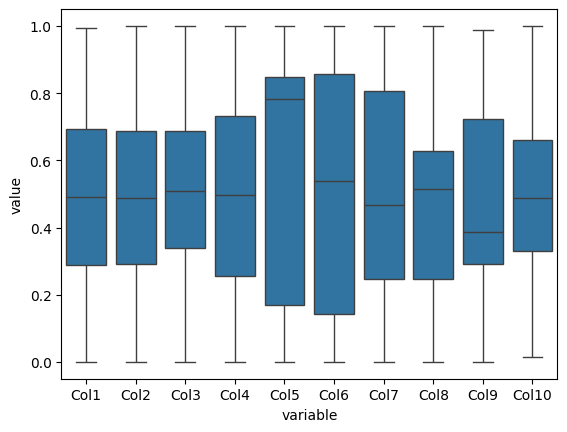

In [5]:
sns.boxplot(x="variable", y="value", data=pd.melt(df))
plt.show()

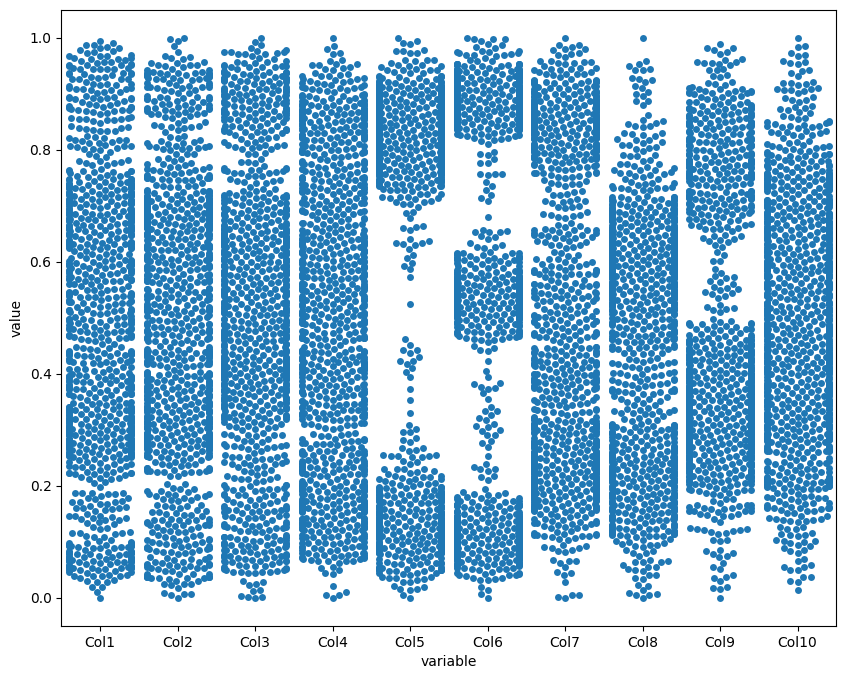

In [6]:
plt.rcParams["figure.figsize"] = (10,8)
sns.swarmplot(x="variable", y="value", data=pd.melt(df))
plt.show()

<Axes: xlabel='Col1', ylabel='Col2'>

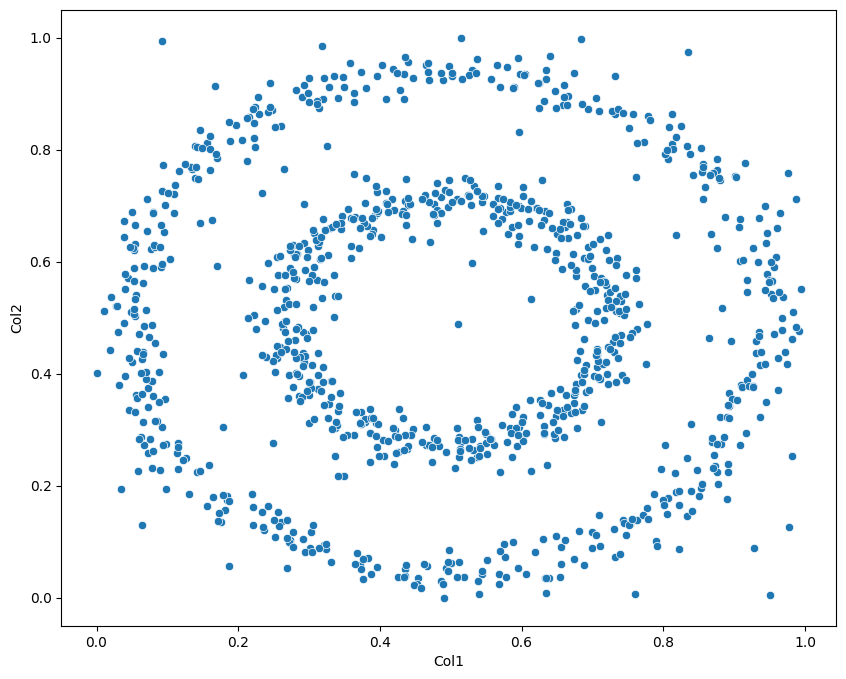

In [7]:
sns.scatterplot(data=df, x="Col1", y='Col2')

<Axes: xlabel='Col3', ylabel='Col4'>

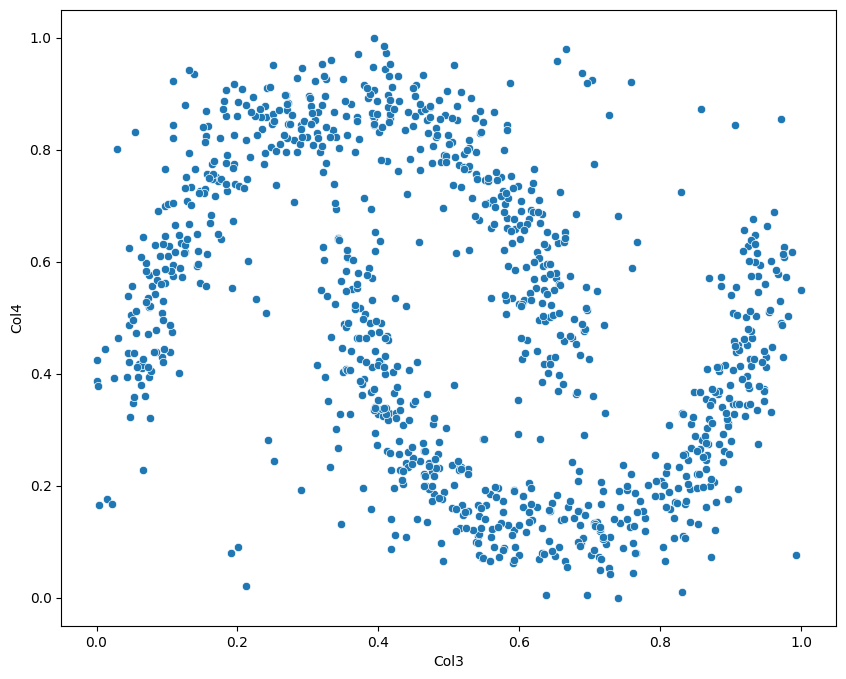

In [8]:
sns.scatterplot(data=df, x="Col3", y='Col4')

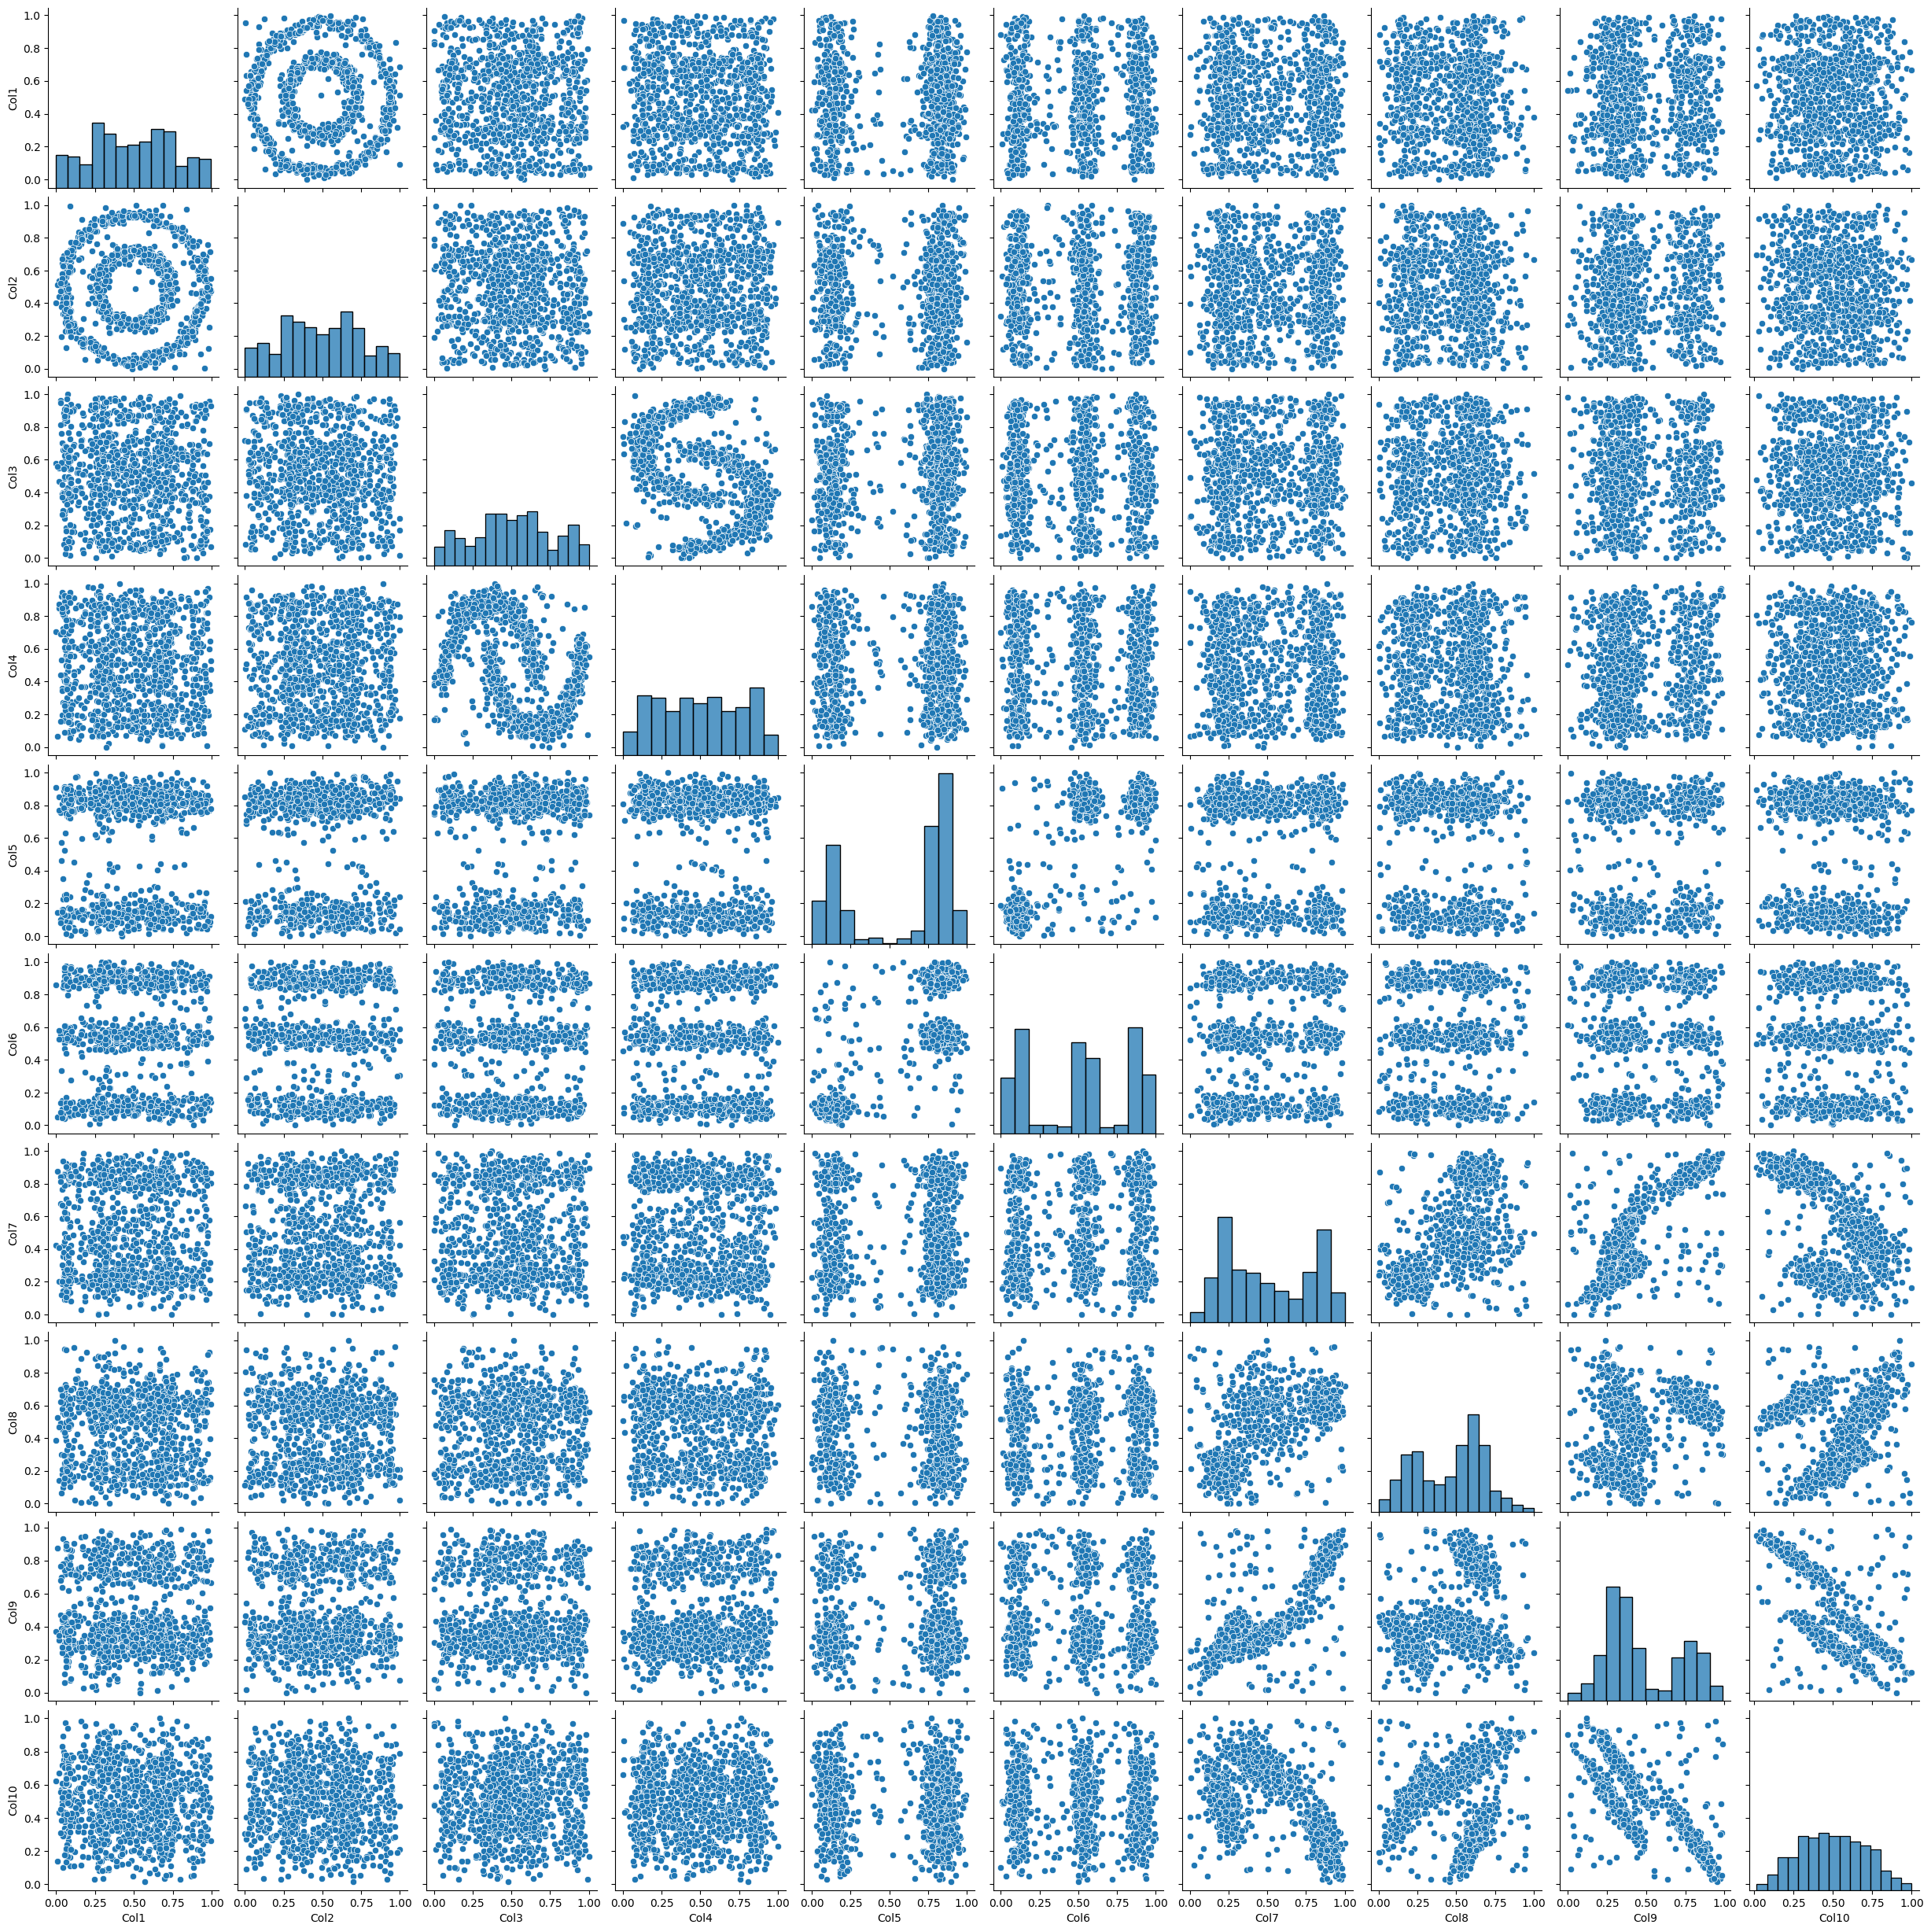

In [9]:
sns.pairplot(df)

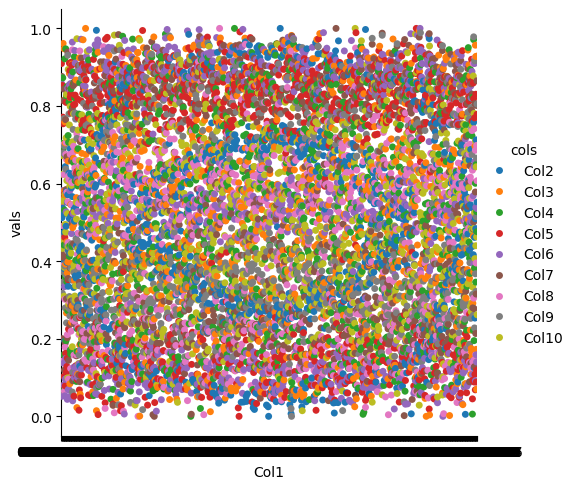

In [10]:
df1 = df.melt('Col1', var_name='cols',  value_name='vals')
g = sns.catplot(x="Col1", y="vals", hue='cols', data=df1)

In [11]:
from pycaret.anomaly import *
exp_01 = setup(df, session_id = 123)

,Description,Value
0,Session id,123
1,Original data shape,"(1000, 10)"
2,Transformed data shape,"(1000, 10)"
3,Numeric features,10
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


In [12]:
models()

,Name,Reference
ID,,
abod,Angle-base Outlier Detection,pyod.models.abod.ABOD
cluster,Clustering-Based Local Outlier,pycaret.internal.patches.pyod.CBLOFForceToDouble
cof,Connectivity-Based Local Outlier,pyod.models.cof.COF
iforest,Isolation Forest,pyod.models.iforest.IForest
histogram,Histogram-based Outlier Detection,pyod.models.hbos.HBOS
knn,K-Nearest Neighbors Detector,pyod.models.knn.KNN
lof,Local Outlier Factor,pyod.models.lof.LOF
svm,One-class SVM detector,pyod.models.ocsvm.OCSVM
pca,Principal Component Analysis,pyod.models.pca.PCA


In [13]:
iforest = create_model('iforest')

In [14]:
print(iforest)

IForest(behaviour='new', bootstrap=False, contamination=0.05,
    max_features=1.0, max_samples='auto', n_estimators=100, n_jobs=-1,
    random_state=123, verbose=0)


In [15]:
lof = create_model('lof')

In [16]:
print(lof)

LOF(algorithm='auto', contamination=0.05, leaf_size=30, metric='minkowski',
  metric_params=None, n_jobs=-1, n_neighbors=20, novelty=True, p=2)


In [17]:
iforest_results = assign_model(iforest)
iforest_results.head()

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10,Anomaly,Anomaly_Score
0,0.263995,0.764929,0.138424,0.935242,0.605867,0.518790,0.912225,0.608234,0.723782,0.733591,0,-0.035865
1,0.546092,0.653975,0.065575,0.227772,0.845269,0.837066,0.272379,0.331679,0.429297,0.367422,0,-0.084927
2,0.336714,0.538842,0.192801,0.553563,0.074515,0.332993,0.365792,0.861309,0.899017,0.088600,1,0.025356
3,0.092108,0.995017,0.014465,0.176371,0.241530,0.514724,0.562208,0.158963,0.073715,0.208463,1,0.042415
4,0.325261,0.805968,0.957033,0.331665,0.307923,0.355315,0.501899,0.558449,0.885169,0.182754,0,-0.023408


In [18]:
lof_results = assign_model(lof)
lof_results.head()

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10,Anomaly,Anomaly_Score
0,0.263995,0.764929,0.138424,0.935242,0.605867,0.518790,0.912225,0.608234,0.723782,0.733591,0,1.262566
1,0.546092,0.653975,0.065575,0.227772,0.845269,0.837066,0.272379,0.331679,0.429297,0.367422,0,1.043429
2,0.336714,0.538842,0.192801,0.553563,0.074515,0.332993,0.365792,0.861309,0.899017,0.088600,0,1.331218
3,0.092108,0.995017,0.014465,0.176371,0.241530,0.514724,0.562208,0.158963,0.073715,0.208463,1,1.591832
4,0.325261,0.805968,0.957033,0.331665,0.307923,0.355315,0.501899,0.558449,0.885169,0.182754,0,1.223608


In [19]:
plot_model(iforest)

In [20]:
plot_model(lof, plot = 'umap', save=True)

'UMAP Dimensionality Plot.png'

In [21]:
save_model(iforest,'IForest_Model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Col1', 'Col2', 'Col3', 'Col4',
                                              'Col5', 'Col6', 'Col7', 'Col8',
                                              'Col9', 'Col10'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('trained_model',
                  IForest(behaviour='new', bootstrap=False, contamination=0.05,
     max_features=1.0, max_samples='auto', n_estimators=100, n_jobs=-1,
     random_state=123, verbose=0))]),
 'IForest_Model.pkl')

In [22]:
from yellowbrick.text import UMAPVisualizer

In [23]:
dfr = iforest_results['Anomaly']

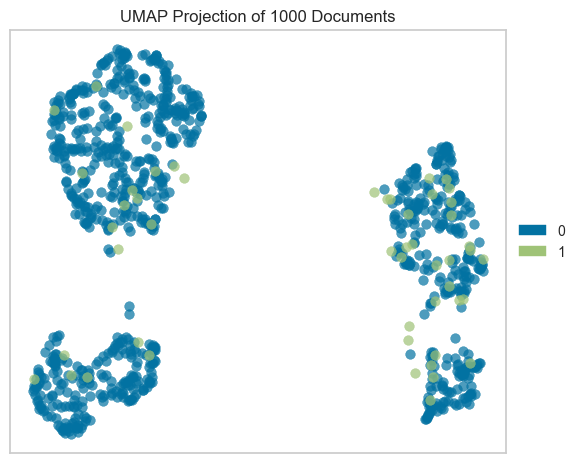

<Axes: title={'center': 'UMAP Projection of 1000 Documents'}>

In [24]:
umap = UMAPVisualizer()
umap.fit(df, dfr)
umap.show()

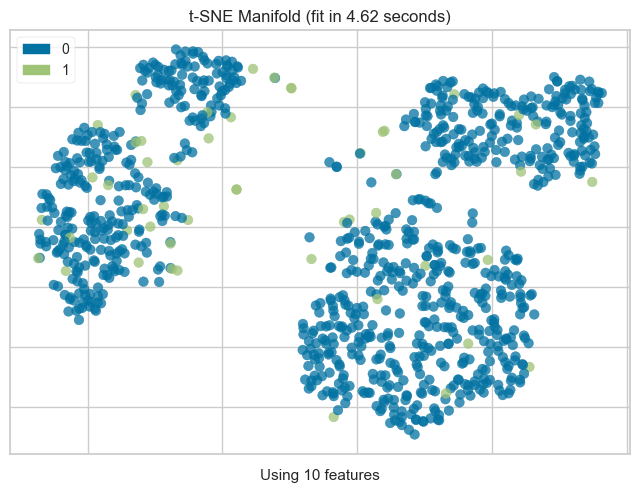

<Axes: title={'center': 't-SNE Manifold (fit in 4.62 seconds)'}, xlabel='Using 10 features'>

In [25]:
from yellowbrick.features import Manifold

viz = Manifold(manifold="tsne")

viz.fit_transform(df, dfr)
viz.show() 

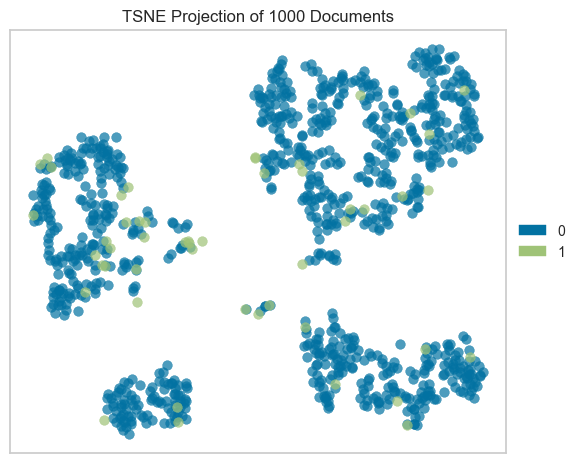

<Axes: title={'center': 'TSNE Projection of 1000 Documents'}>

In [26]:
from yellowbrick.text import TSNEVisualizer

tsne = TSNEVisualizer(decompose_by=4) #changing number changes style of TSNE
tsne.fit(df, dfr)
tsne.show()